# ResNet vs MLP

Насколько вы можете знать, в глубоких MLP сетях сигнал может затухать или же напротив взрываться, проходя через множество слоев. Пусть у нас есть сеть из $L$ слоёв и каждый слой считает: $$h_{l+1} = \sigma(W_l h_l + b_l)$$

Тогда градиент по весам начальных слоев будет включать в себя произведение матриц весов и производную функцию функции активации всех последующих слоев _(просто по правилу сложной производной)_, то есть: 

$$\frac{\partial \mathcal{L}}{\partial W_1} \propto \prod_{l=2}^{L} \underbrace{\operatorname{diag}\left(\sigma^{\prime}\left(z_l\right)\right) \cdot W_l}_{J_l}$$

$J_l$ - это матрица Якоби $l$-го слоя. Как раз-таки она и решает судьбу градиента.

Как мы можем знать из курса ОМВ, $$\left\|\prod_{l=2}^L J_l\right\| \leq \prod_{l=2}^L\left\|J_l\right\|$$

Поэтому если каждый слой чуть-чуть сжимает норму, например, на коэффициент $c$, то через L слоев градиент будет убывать как $c^L$. Экспоненциальное затухание!

Откуда же берется это сжатие (ну или напротив расжатие)? Ну, из формулы видно, что виновата функция активации или же сами веса. И правда, насчет ф-ий активаций, тот же $\tanh$ или сигмоида имеют плоские участки, где $\sigma' \to 0$.

**ResNet** решает эту проблему через skip-connections: $$h_{l+1} = \sigma(W_l h_l + b_l) + h_l$$

Благодаря этому градиент может течь напрямую!

$$\frac{\partial (f(h) + h)}{\partial h} = \frac{\partial f}{\partial h} + 1$$

Отсюда и следует, что как будто ResNet должен показать себя лучше, чем MLP именно при глубоких нейросетях. 

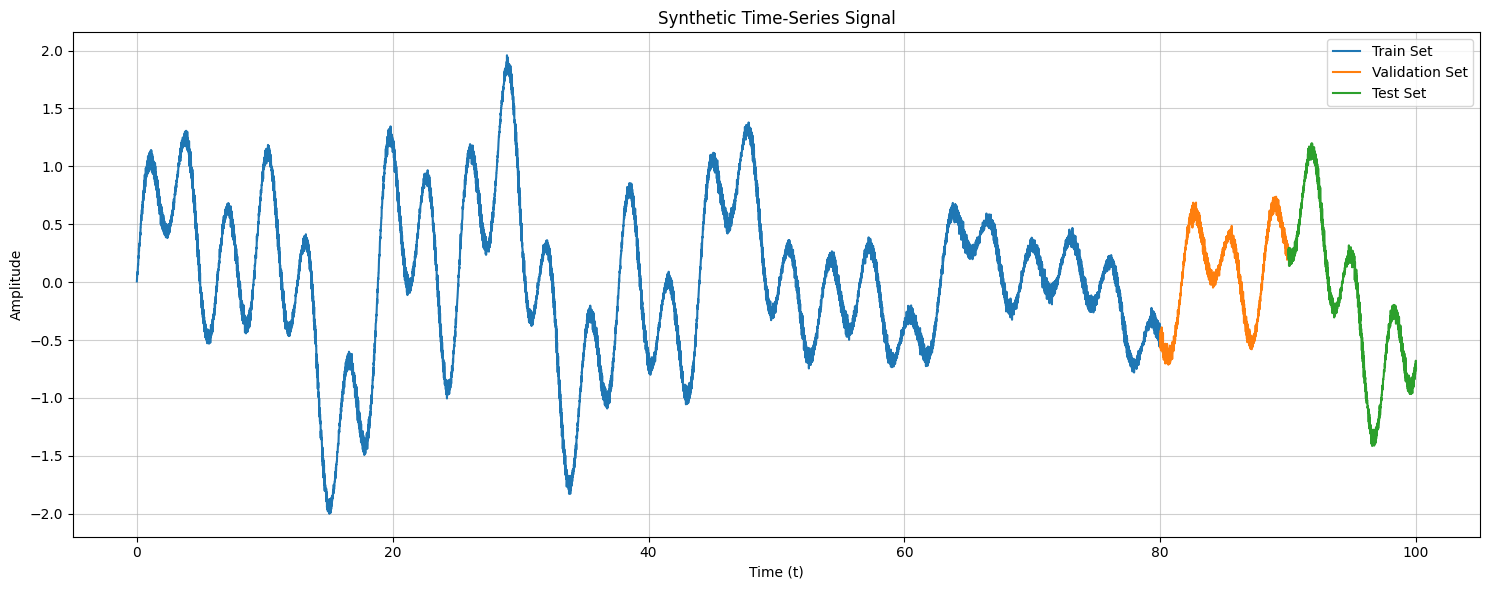

In [11]:
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import generate_signal


def plot_signal(n_points: int = 10_000, train_split: float = 0.8, val_split: float = 0.1, seed: int = 57):
    signal = generate_signal(n_points, seed=seed)
    t = np.linspace(0, 100, n_points)
    
    tr_end = int(n_points * train_split)
    val_end = int(n_points * (train_split + val_split))

    plt.figure(figsize=(15, 6))

    plt.plot(t[:tr_end], signal[:tr_end], label='Train Set')
    plt.plot(t[tr_end:val_end], signal[tr_end:val_end], label='Validation Set')
    plt.plot(t[val_end:], signal[val_end:], label='Test Set')

    plt.title('Synthetic Time-Series Signal')
    plt.xlabel('Time (t)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_signal()

В общем, цель данной работы - сравнить способности ResNet и MLP аппроксимировать сложные нелинейные зависимости. Задачу я сформулировал как обучение с учителем. Модель получает на вход вектор из последних $N$ наблюдений и должна предсказать следующее значение.

Для этого я сгенерировал данные. Мой сигнал включает в себя комбинации $\sin$ и $\cos$, детерминированный хаос и гауссовский шум.

Эти данные имеют высокую нелинейность, что, в целом, уже видно по графику, поэтому обычный линрег тут не справится. Чтобы уловить какие-то законномерности, придется увеличивать глубину моделей. А это мы уже и будем изучать!

Ладно, идем смотреть на результаты $:)$

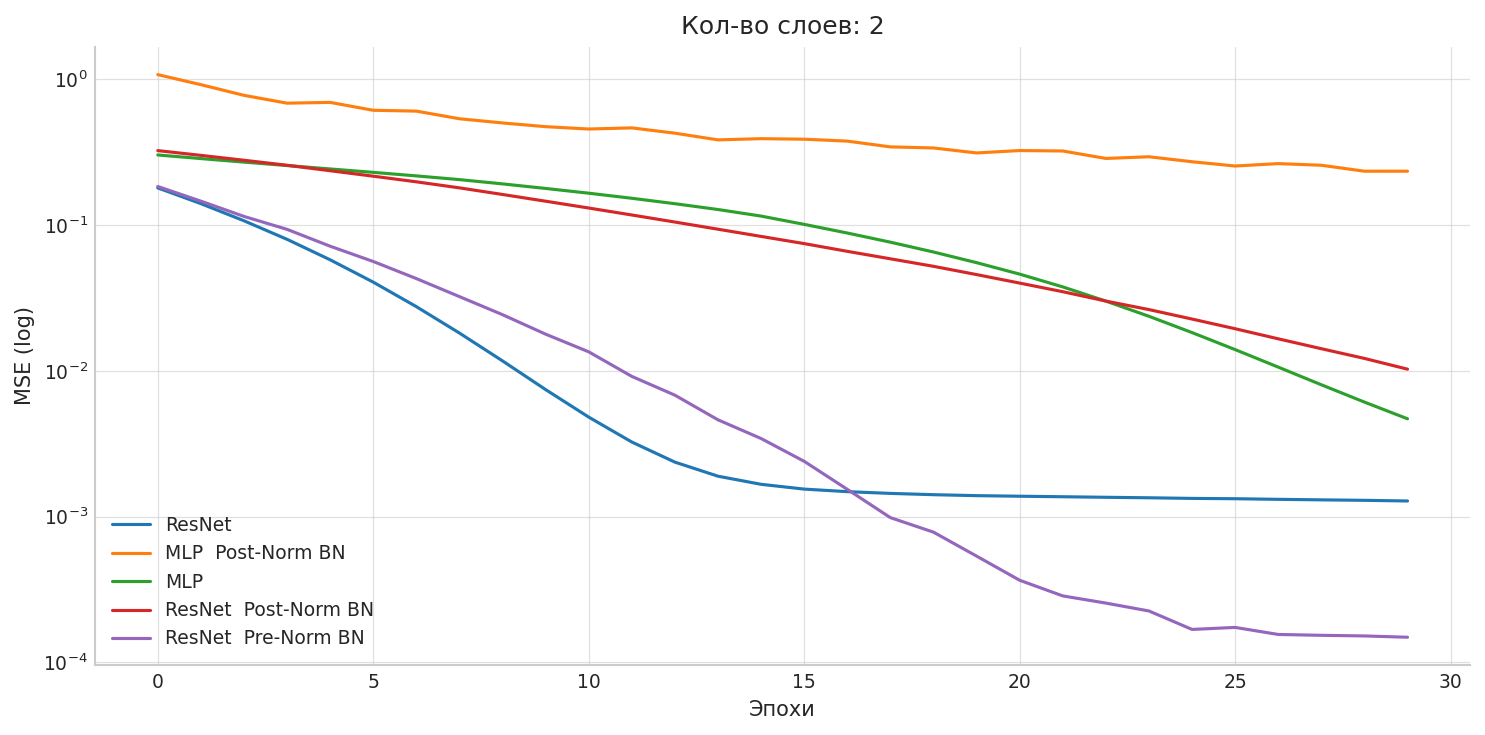

------------------------------


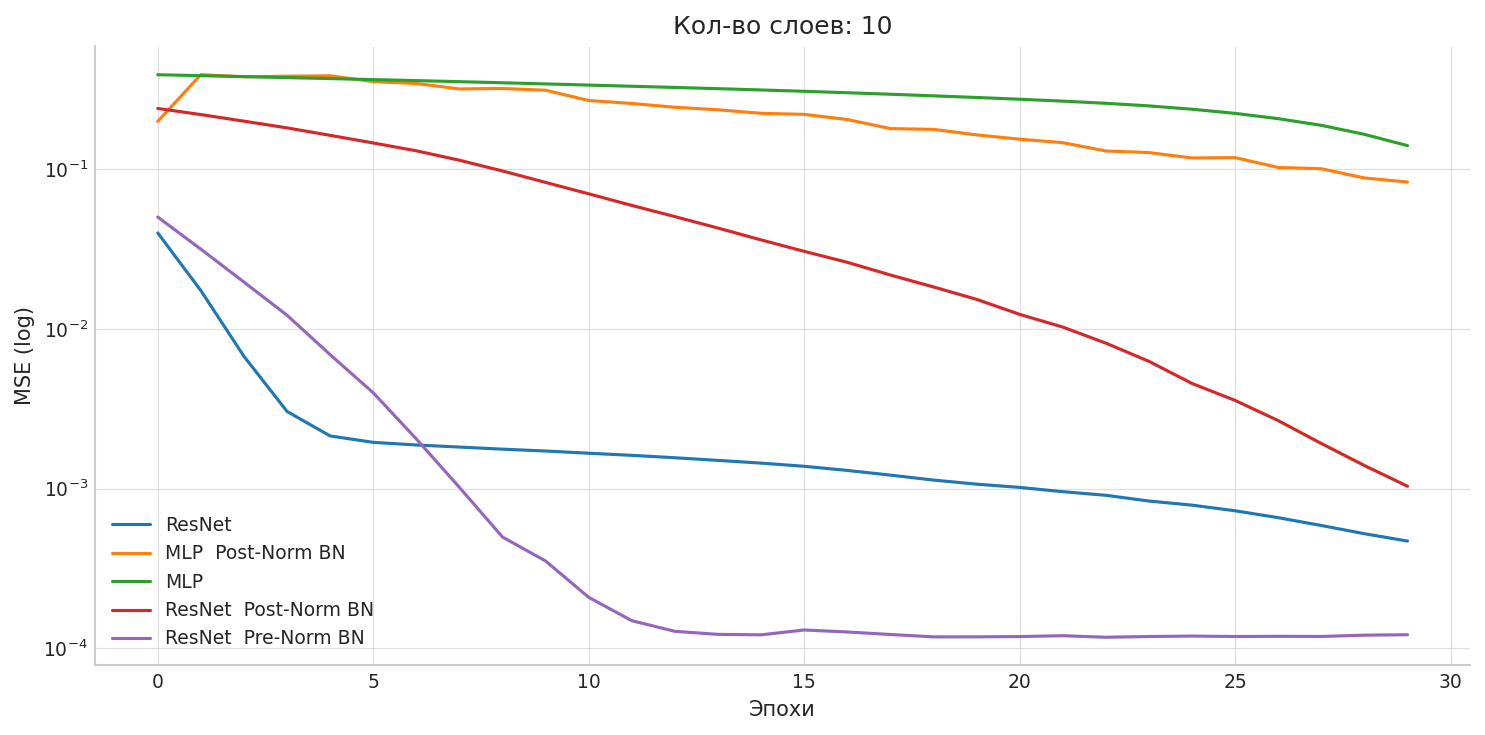

------------------------------


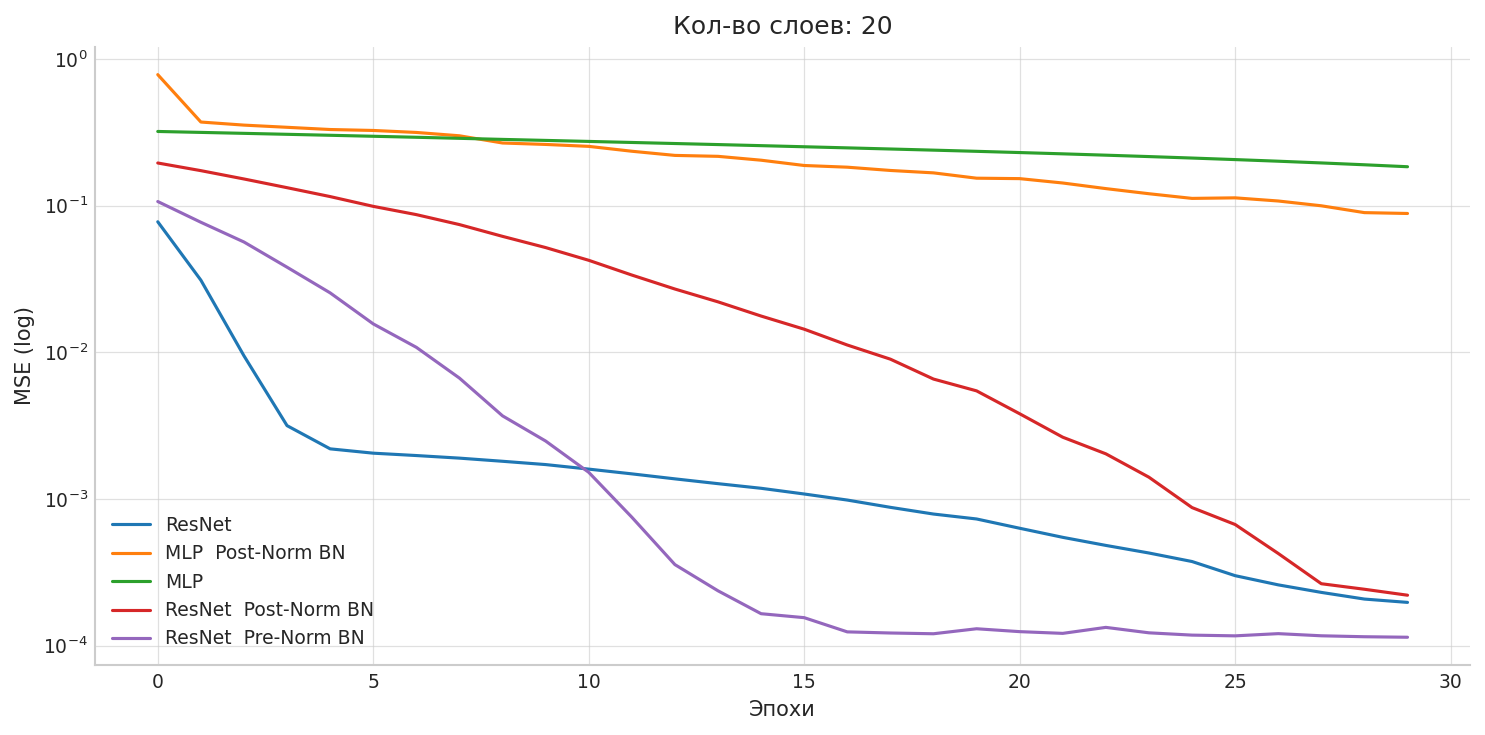

------------------------------


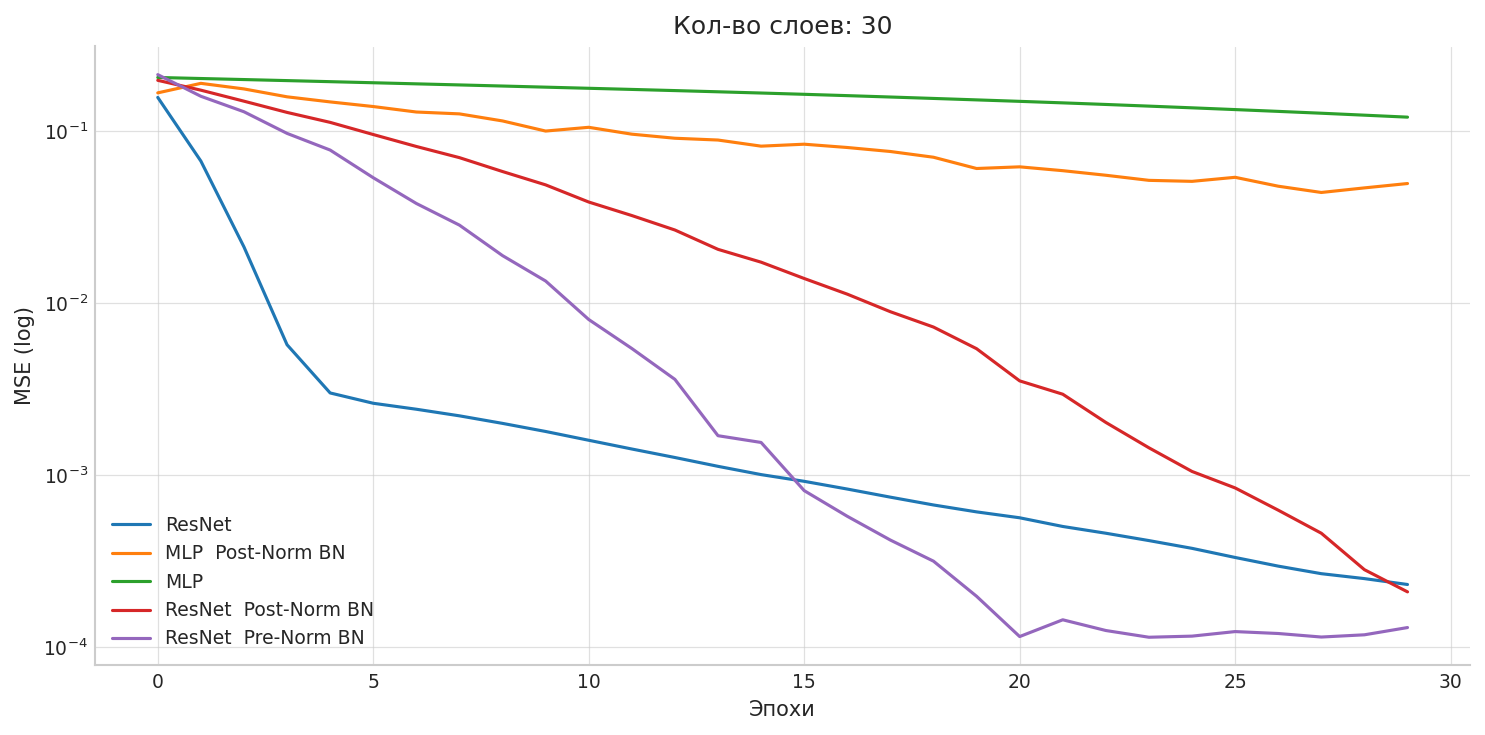

------------------------------


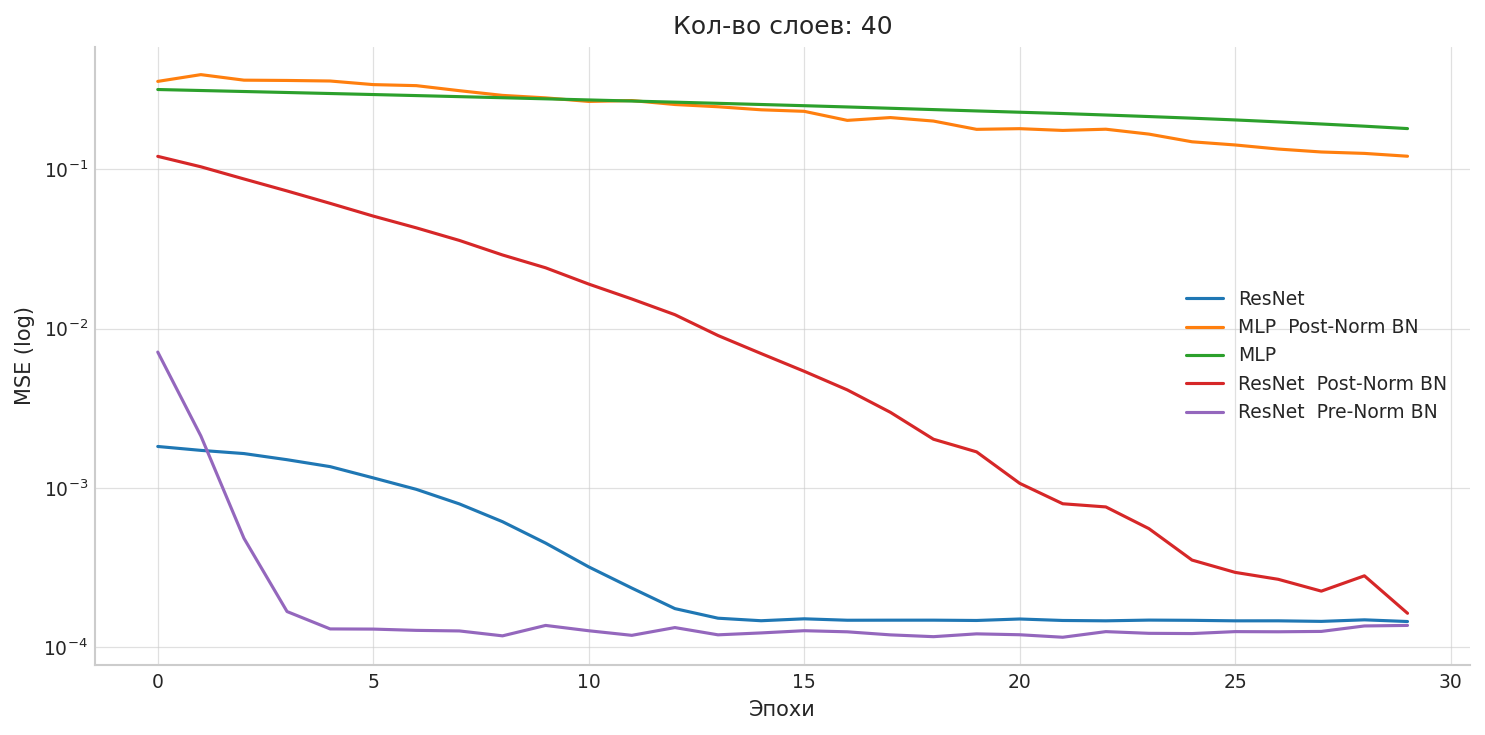

------------------------------


In [ ]:
import json

file_path = 'experiments/history.json'
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

depths = sorted(list(set(item['depth'] for item in data.values())))

for d in depths:
    plt.figure(figsize=(10, 5))
    found_data = False
    
    for name, results in data.items():
        if results['depth'] == d:
            val_history = results['history']['val']
            full_name = results['architecture']

            if '(no BN)' in full_name:
                clean_label = full_name.split('+')[0].replace('(no BN)', '').strip()
            else:
                clean_label = full_name.split('+')[0] + full_name.split('+')[1]        
                    
            plt.plot(val_history, label=clean_label)
            found_data = True
            
    if found_data:
        layers = d * 2
        plt.title(f"Кол-во слоев: {layers}")
        
        plt.yscale('log')
        plt.xlabel('Эпохи')
        plt.ylabel('MSE (log)')
        
        plt.grid(alpha=0.6)
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f"{'-' * 30}")

Как мы видим, графики показывают нам ту самую degradation problem.

На малой глубине MLP еще неплохо справляется. Однако начиная с 10 слоев, ее кривая становится все более пологой. От 30 слоев MLP уже практически не снижает ошибку, по сути сеть мертва, так как градиенты затухают настолько сильно, что веса начальных слоев уже не обновляются. 

В отличие от MLP, ResNet показал хорошие результаты. Он продолжал обучаться на любой глубине.

Далее мной был внедрен BN для стабилизации выходов слоев. На малых глубинах BN еще как-то спасал MLP, но и все. Он не решает проблему деградации полностью.

Но самым лучшим оказался ResNet PreNorm, так как по сути она нормализует вход в блок, то есть весам не приходится постоянно перестраиваться под новую дисперсию, но также он еще оставляет identity путь для градиента чистым! 